<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_10_strategy/stage_10_strategy_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_10 - Strategy design**

# **1. Imports**

In [3]:
# Permite anotaciones modernas en Python < 3.11
from __future__ import annotations

# ================================
# Standard library (mínimo necesario)
# ================================
import os
import sys
import warnings
import logging
from pathlib import Path

# ================================
# Third-party
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Configuración global
# ================================

# ---- Warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Logging limpio
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.propagate = False

if logger.handlers:
    logger.handlers.clear()

handler = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
handler.setFormatter(formatter)
logger.addHandler(handler)

logger.info("Environment initialized")

# ---- Pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# ---- Estilo plots
sns.set(style="whitegrid")

2026-04-25 02:47:22,290 | INFO | Environment initialized


# **2. Acceso a drive**

In [2]:
# ================================
# Entorno (Google Drive / local)
# ================================

from pathlib import Path
import os

# Detectar si estamos en Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DEFAULT_DRIVE_DIR = "/content/drive/MyDrive/neural_profit/"
else:
    # fallback local (puedes ajustarlo si quieres)
    DEFAULT_DRIVE_DIR = "./neural_profit/"

# Ruta base del proyecto
DRIVE_DIR = Path(os.environ.get("DRIVE_DIR", DEFAULT_DRIVE_DIR))

# Validación básica
if not DRIVE_DIR.exists():
    logger.warning(f"DRIVE_DIR no existe: {DRIVE_DIR}")
else:
    logger.info(f"DRIVE_DIR: {DRIVE_DIR}")

2026-04-25 02:43:26,965 | INFO | DRIVE_DIR: /content/drive/MyDrive/neural_profit


Mounted at /content/drive


# **3. Rutas de métricas y probabilidades**

In [7]:
# =========================================
# Base path
# =========================================
BEST_MODELS_DIR = Path("/content/drive/MyDrive/neural_profit/best_models")

# =========================================
# Paths de modelos
# =========================================
LR_FINAL_BALANCED_DIR = BEST_MODELS_DIR / os.environ.get(
    "LR_FINAL_BALANCED_DIR",
    "lr_final_balanced/"
)

GRU_FINAL_BASELINE_DIR = BEST_MODELS_DIR / os.environ.get(
    "GRU_FINAL_BASELINE_DIR",
    "gru_final_baseline/"
)



In [15]:
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# **4. Carga de datasets OOS (post modelo final)**

In [18]:
# =========================================================
# 4. Carga de datasets OOS (post modelo final)
# =========================================================

# Rutas relativas a BEST_MODELS_DIR
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# -------------------------------
# Validación de existencia
# -------------------------------
assert METRICS_OOS_DIR.exists(), f"No existe: {METRICS_OOS_DIR}"
assert PROBA_OOS_DIR.exists(), f"No existe: {PROBA_OOS_DIR}"

logger.info(f"Cargando métricas OOS desde: {METRICS_OOS_DIR}")
logger.info(f"Cargando probabilidades OOS desde: {PROBA_OOS_DIR}")

# -------------------------------
# Carga de datos
# -------------------------------
df_metrics_oos = pd.read_parquet(METRICS_OOS_DIR)
df_prob_oos = pd.read_parquet(PROBA_OOS_DIR)

# -------------------------------
# Inspección básica
# -------------------------------
print("=" * 80)
print("DATASETS OOS CARGADOS")
print("=" * 80)

print("df_metrics_oos:", df_metrics_oos.shape)
print("df_prob_oos   :", df_prob_oos.shape)

print("\nColumnas df_prob_oos:")
print(df_prob_oos.columns.tolist())

print("\nSplits disponibles:", df_prob_oos["split"].unique())
print("Targets disponibles:", df_prob_oos["target"].unique())
print("Modelos disponibles:", df_prob_oos["model"].unique())

print("=" * 80)

2026-04-25 03:06:14,366 | INFO | Cargando métricas OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_metrics_oos_valid_test.parquet
2026-04-25 03:06:14,367 | INFO | Cargando probabilidades OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_probabilities_oos_valid_test.parquet


DATASETS OOS CARGADOS
df_metrics_oos: (6, 34)
df_prob_oos   : (41385, 18)

Columnas df_prob_oos:
['proba_-1', 'proba_0', 'proba_1', 'pred_label', 'confidence', 'y_true', 'is_correct', 'signal_raw', 'trade', 'experiment_name', 'model', 'split', 'window_size', 'target', 'horizon', 'threshold_long', 'threshold_short', 'class_labels']

Splits disponibles: ['test' 'valid']
Targets disponibles: ['t2_p40_h30']
Modelos disponibles: ['gru' 'logistic_regression' 'xgboost']


# **5. Selección de datos OOS para diseño de estrategia**


In [19]:
# =========================================================
# 5. Selección de datos OOS para diseño de estrategia
# =========================================================

split_strategy = "valid"
target_strategy = "t2_p40_h30"

models_strategy = [
    "gru",
    "logistic_regression",
]

df_strategy_valid = df_prob_oos[
    (df_prob_oos["split"] == split_strategy) &
    (df_prob_oos["target"] == target_strategy) &
    (df_prob_oos["model"].isin(models_strategy))
].copy()

print("=" * 80)
print("DATASET BASE PARA DISEÑO DE ESTRATEGIA")
print("=" * 80)
print(f"Split seleccionado : {split_strategy}")
print(f"Target seleccionado: {target_strategy}")
print(f"Modelos incluidos  : {models_strategy}")
print("-" * 80)
print(df_strategy_valid.shape)
print(df_strategy_valid["model"].value_counts())
print("=" * 80)

DATASET BASE PARA DISEÑO DE ESTRATEGIA
Split seleccionado : valid
Target seleccionado: t2_p40_h30
Modelos incluidos  : ['gru', 'logistic_regression']
--------------------------------------------------------------------------------
(13764, 18)
model
gru                    6882
logistic_regression    6882
Name: count, dtype: int64


In [20]:
# =========================================================
# 6. Separación GRU / Logistic Regression
# =========================================================

df_gru_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "gru"]
    .reset_index(drop=True)
    .copy()
)

df_lr_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "logistic_regression"]
    .reset_index(drop=True)
    .copy()
)

# Validación de alineación
assert len(df_gru_valid) == len(df_lr_valid), "GRU y LR no tienen la misma cantidad de muestras."

assert (df_gru_valid["y_true"].values == df_lr_valid["y_true"].values).all(), (
    "Las etiquetas y_true no están alineadas entre GRU y LR."
)

print("=" * 80)
print("VALIDACIÓN DE ALINEACIÓN")
print("=" * 80)
print(f"GRU valid: {df_gru_valid.shape}")
print(f"LR  valid: {df_lr_valid.shape}")
print("OK: GRU y LR están alineados muestra a muestra.")
print("=" * 80)

VALIDACIÓN DE ALINEACIÓN
GRU valid: (6882, 18)
LR  valid: (6882, 18)
OK: GRU y LR están alineados muestra a muestra.


# **7. Dataset comparativo GRU vs LR**

In [21]:
# =========================================================
# 7. Dataset comparativo GRU vs LR
# =========================================================

df_valid_cmp = pd.DataFrame({
    "y_true": df_gru_valid["y_true"].values,

    # Probabilidades GRU
    "gru_proba_-1": df_gru_valid["proba_-1"].values,
    "gru_proba_0":  df_gru_valid["proba_0"].values,
    "gru_proba_1":  df_gru_valid["proba_1"].values,
    "gru_pred_label": df_gru_valid["pred_label"].values,
    "gru_signal_raw": df_gru_valid["signal_raw"].values,
    "gru_trade": df_gru_valid["trade"].values,

    # Probabilidades LR
    "lr_proba_-1": df_lr_valid["proba_-1"].values,
    "lr_proba_0":  df_lr_valid["proba_0"].values,
    "lr_proba_1":  df_lr_valid["proba_1"].values,
    "lr_pred_label": df_lr_valid["pred_label"].values,
    "lr_signal_raw": df_lr_valid["signal_raw"].values,
    "lr_trade": df_lr_valid["trade"].values,
})

print("=" * 80)
print("DATASET COMPARATIVO VALID")
print("=" * 80)
print(df_valid_cmp.shape)
display(df_valid_cmp.head())

DATASET COMPARATIVO VALID
(6882, 13)


,y_true,gru_proba_-1,gru_proba_0,gru_proba_1,gru_pred_label,gru_signal_raw,gru_trade,lr_proba_-1,lr_proba_0,lr_proba_1,lr_pred_label,lr_signal_raw,lr_trade
0,1,0.224806,0.504271,0.270923,0,0,False,0.204912,0.537222,0.257866,0,0,False
1,1,0.230340,0.502102,0.267557,0,0,False,0.219718,0.490672,0.289610,0,0,False
2,1,0.236065,0.498919,0.265016,0,0,False,0.233783,0.471314,0.294903,0,0,False
3,1,0.240946,0.497206,0.261848,0,0,False,0.223747,0.484658,0.291594,0,0,False
4,1,0.241786,0.500210,0.258004,0,0,False,0.215719,0.515898,0.268383,0,0,False


In [22]:
# =========================================================
# 8. Actividad de cada modelo
# =========================================================

print("=" * 80)
print("ACTIVIDAD DE MODELOS")
print("=" * 80)

gru_trade_rate = df_valid_cmp["gru_trade"].mean()
lr_trade_rate  = df_valid_cmp["lr_trade"].mean()

print(f"GRU trade_rate: {gru_trade_rate:.4f}")
print(f"LR  trade_rate: {lr_trade_rate:.4f}")

ACTIVIDAD DE MODELOS
GRU trade_rate: 0.2457
LR  trade_rate: 0.1507


In [26]:
# =========================================================
# 8. Actividad de cada modelo
# =========================================================

print("=" * 80)
print("ACTIVIDAD DE MODELOS")
print("=" * 80)

gru_trade_rate = df_valid_cmp["gru_trade"].mean()
lr_trade_rate  = df_valid_cmp["lr_trade"].mean()

print(f"GRU trade_rate: {gru_trade_rate:.4f}")
print(f"LR  trade_rate: {lr_trade_rate:.4f}")

# =========================================================
# 9. Precisión útil por modelo
# =========================================================

# GRU
df_gru_trades = df_valid_cmp[df_valid_cmp["gru_trade"]]

gru_precision = (df_gru_trades["gru_pred_label"] == df_gru_trades["y_true"]).mean()

# LR
df_lr_trades = df_valid_cmp[df_valid_cmp["lr_trade"]]

lr_precision = (df_lr_trades["lr_pred_label"] == df_lr_trades["y_true"]).mean()

print("=" * 80)
print("PRECISIÓN CONDICIONAL (CUANDO OPERAN)")
print("=" * 80)

print(f"GRU precision: {gru_precision:.4f}")
print(f"LR  precision: {lr_precision:.4f}")

# =========================================================
# 10. Interacción GRU vs LR
# =========================================================

df_valid_cmp["both_trade"] = df_valid_cmp["gru_trade"] & df_valid_cmp["lr_trade"]
df_valid_cmp["only_gru"]   = df_valid_cmp["gru_trade"] & (~df_valid_cmp["lr_trade"])
df_valid_cmp["only_lr"]    = df_valid_cmp["lr_trade"] & (~df_valid_cmp["gru_trade"])

print("=" * 80)
print("INTERACCIÓN DE SEÑALES")
print("=" * 80)

print("Ambos operan :", df_valid_cmp["both_trade"].sum())
print("Solo GRU     :", df_valid_cmp["only_gru"].sum())
print("Solo LR      :", df_valid_cmp["only_lr"].sum())

# =========================================================
# 11. Precisión por tipo de señal
# =========================================================

def precision_subset(df, pred_col):
    if len(df) == 0:
        return np.nan
    return (df[pred_col] == df["y_true"]).mean()

# Ambos operan → usamos GRU como referencia (podés cambiar luego)
df_both = df_valid_cmp[df_valid_cmp["both_trade"]]

# Solo GRU
df_only_gru = df_valid_cmp[df_valid_cmp["only_gru"]]

# Solo LR
df_only_lr = df_valid_cmp[df_valid_cmp["only_lr"]]

print("=" * 80)
print("PRECISIÓN POR ESCENARIO")
print("=" * 80)

print(f"Ambos (GRU ref): {precision_subset(df_both, 'gru_pred_label'):.4f}")
print(f"Solo GRU      : {precision_subset(df_only_gru, 'gru_pred_label'):.4f}")
print(f"Solo LR       : {precision_subset(df_only_lr, 'lr_pred_label'):.4f}")

ACTIVIDAD DE MODELOS
GRU trade_rate: 0.2457
LR  trade_rate: 0.1507
PRECISIÓN CONDICIONAL (CUANDO OPERAN)
GRU precision: 0.4530
LR  precision: 0.4744
INTERACCIÓN DE SEÑALES
Ambos operan : 712
Solo GRU     : 979
Solo LR      : 325
PRECISIÓN POR ESCENARIO
Ambos (GRU ref): 0.4452
Solo GRU      : 0.4586
Solo LR       : 0.4308


# **11. Análisis de distribución de probabilidades GRU vs LR**

ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES


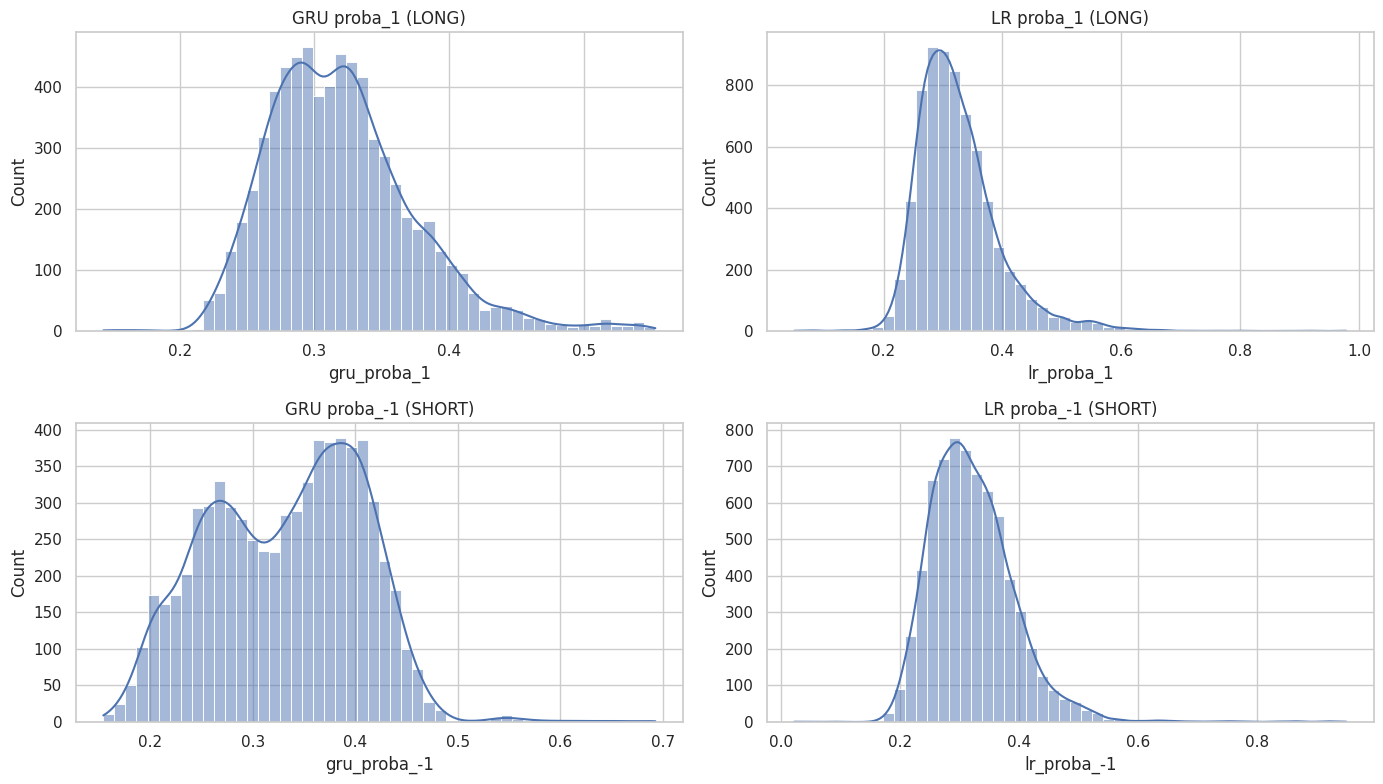

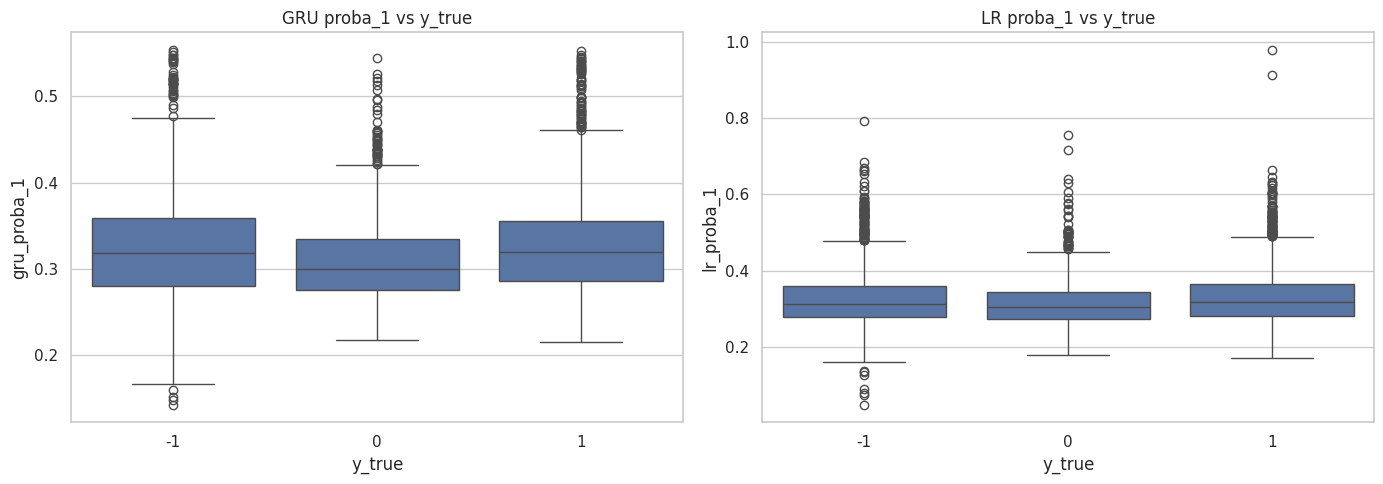

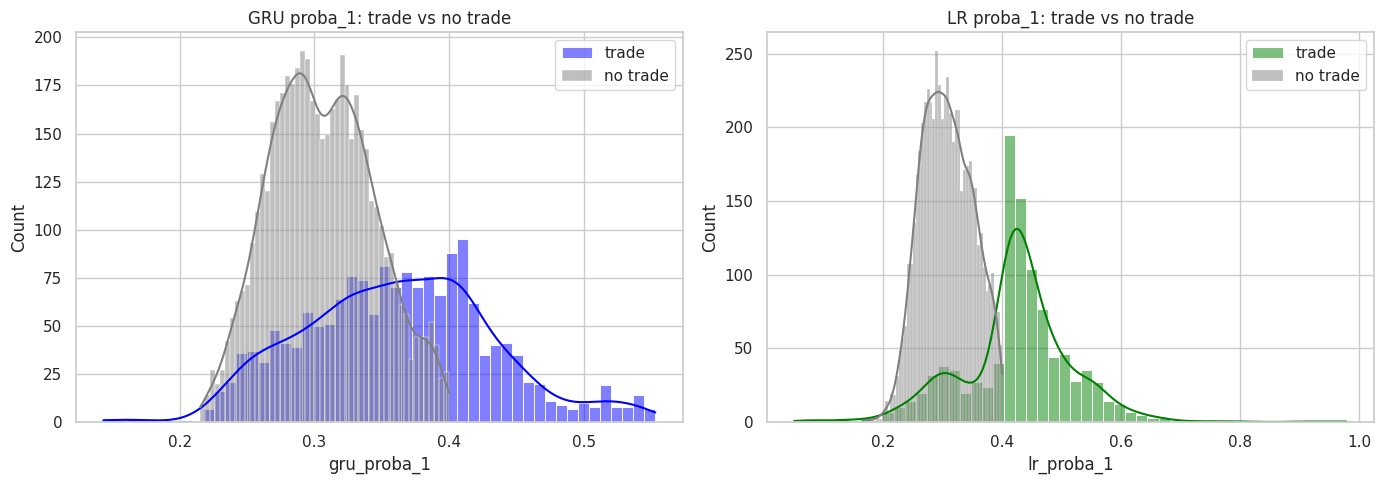

CORRELACIÓN ENTRE MODELOS
Corr LONG  (proba_1):  0.5735
Corr SHORT (proba_-1): 0.7086


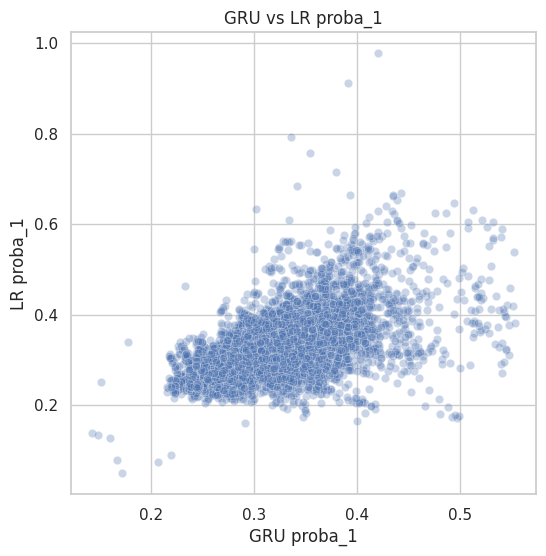

In [27]:
# =========================================================
# 12. Análisis de probabilidades GRU vs LR
# =========================================================

print("=" * 80)
print("ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES")
print("=" * 80)

# ---------------------------------------------------------
# 1. Histogramas de probabilidades (long y short)
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# GRU proba_1 (long)
sns.histplot(df_valid_cmp["gru_proba_1"], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("GRU proba_1 (LONG)")

# LR proba_1 (long)
sns.histplot(df_valid_cmp["lr_proba_1"], bins=50, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("LR proba_1 (LONG)")

# GRU proba_-1 (short)
sns.histplot(df_valid_cmp["gru_proba_-1"], bins=50, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("GRU proba_-1 (SHORT)")

# LR proba_-1 (short)
sns.histplot(df_valid_cmp["lr_proba_-1"], bins=50, ax=axes[1, 1], kde=True)
axes[1, 1].set_title("LR proba_-1 (SHORT)")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Probabilidades vs clase real
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_valid_cmp, x="y_true", y="gru_proba_1", ax=axes[0])
axes[0].set_title("GRU proba_1 vs y_true")

sns.boxplot(data=df_valid_cmp, x="y_true", y="lr_proba_1", ax=axes[1])
axes[1].set_title("LR proba_1 vs y_true")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Probabilidades en trades vs no trades
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df_valid_cmp[df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    color="blue",
    label="trade",
    ax=axes[0],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    color="gray",
    label="no trade",
    ax=axes[0],
    kde=True
)

axes[0].legend()
axes[0].set_title("GRU proba_1: trade vs no trade")


sns.histplot(
    df_valid_cmp[df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    color="green",
    label="trade",
    ax=axes[1],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    color="gray",
    label="no trade",
    ax=axes[1],
    kde=True
)

axes[1].legend()
axes[1].set_title("LR proba_1: trade vs no trade")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Correlación entre modelos
# ---------------------------------------------------------

corr_long = np.corrcoef(df_valid_cmp["gru_proba_1"], df_valid_cmp["lr_proba_1"])[0, 1]
corr_short = np.corrcoef(df_valid_cmp["gru_proba_-1"], df_valid_cmp["lr_proba_-1"])[0, 1]

print("=" * 80)
print("CORRELACIÓN ENTRE MODELOS")
print("=" * 80)
print(f"Corr LONG  (proba_1):  {corr_long:.4f}")
print(f"Corr SHORT (proba_-1): {corr_short:.4f}")


# ---------------------------------------------------------
# 5. Scatter plot GRU vs LR
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=df_valid_cmp["gru_proba_1"],
    y=df_valid_cmp["lr_proba_1"],
    alpha=0.3
)
plt.title("GRU vs LR proba_1")
plt.xlabel("GRU proba_1")
plt.ylabel("LR proba_1")
plt.show()

# **13. Construcción y comparación de estrategias sobre VALID**

In [28]:
# =========================================================
# 13. Construcción y comparación de estrategias sobre VALID
# =========================================================

df_strat = df_valid_cmp.copy()

# =========================================================
# 1. Función auxiliar para evaluar una estrategia
# =========================================================

def evaluate_strategy(df, signal_col, name):
    """
    Evalúa una estrategia basada en una señal:
        -  1 = long
        - -1 = short
        -  0 = no trade
    """

    signal = df[signal_col]
    y_true = df["y_true"]

    trade_mask = signal != 0
    n_obs = len(df)
    n_trades = trade_mask.sum()

    if n_trades == 0:
        precision_useful = np.nan
        n_useful = 0
    else:
        n_useful = (signal[trade_mask] == y_true[trade_mask]).sum()
        precision_useful = n_useful / n_trades

    trade_rate = n_trades / n_obs
    useful_rate_total = n_useful / n_obs

    return {
        "strategy": name,
        "n_obs": n_obs,
        "n_trades": n_trades,
        "trade_rate": trade_rate,
        "n_useful": n_useful,
        "precision_useful": precision_useful,
        "useful_rate_total": useful_rate_total,
    }


# =========================================================
# 2. Estrategia 1: Baseline GRU
# =========================================================

# Usa directamente la señal ya generada por el modelo GRU
df_strat["signal_gru_baseline"] = df_strat["gru_signal_raw"]


# =========================================================
# 3. Estrategia 2: Baseline LR
# =========================================================

# Usa directamente la señal ya generada por Logistic Regression
df_strat["signal_lr_baseline"] = df_strat["lr_signal_raw"]


# =========================================================
# 4. Estrategia 3: Ensemble promedio simple
# =========================================================

# Score combinado por promedio de probabilidades
df_strat["ens_score_long"] = (
    df_strat["gru_proba_1"] + df_strat["lr_proba_1"]
) / 2

df_strat["ens_score_short"] = (
    df_strat["gru_proba_-1"] + df_strat["lr_proba_-1"]
) / 2

# Threshold inicial conservador
thr_ens_long = 0.40
thr_ens_short = 0.40

df_strat["signal_ensemble_avg"] = 0

df_strat.loc[
    df_strat["ens_score_long"] >= thr_ens_long,
    "signal_ensemble_avg"
] = 1

df_strat.loc[
    df_strat["ens_score_short"] >= thr_ens_short,
    "signal_ensemble_avg"
] = -1

# Resolver conflictos: si long y short superan threshold, elegir el score mayor
conflict_mask = (
    (df_strat["ens_score_long"] >= thr_ens_long) &
    (df_strat["ens_score_short"] >= thr_ens_short)
)

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] > df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_short"] > df_strat["ens_score_long"]),
    "signal_ensemble_avg"
] = -1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] == df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 0


# =========================================================
# 5. Estrategia 4: LR dominante + GRU complemento
# =========================================================

# Idea:
# - LR decide cuando tiene alta confianza.
# - Si LR no opera, GRU puede aportar señal secundaria.
# - Evitamos operar GRU si LR contradice claramente.

thr_lr_long_main = 0.45
thr_lr_short_main = 0.45

thr_gru_long_secondary = 0.42
thr_gru_short_secondary = 0.42

df_strat["signal_lr_gru_hybrid"] = 0

# LR dominante
df_strat.loc[
    df_strat["lr_proba_1"] >= thr_lr_long_main,
    "signal_lr_gru_hybrid"
] = 1

df_strat.loc[
    df_strat["lr_proba_-1"] >= thr_lr_short_main,
    "signal_lr_gru_hybrid"
] = -1

# GRU complemento solo si LR no decidió
no_signal_mask = df_strat["signal_lr_gru_hybrid"] == 0

df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_1"] >= thr_gru_long_secondary) &
    (df_strat["lr_proba_-1"] < thr_lr_short_main),
    "signal_lr_gru_hybrid"
] = 1

df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_-1"] >= thr_gru_short_secondary) &
    (df_strat["lr_proba_1"] < thr_lr_long_main),
    "signal_lr_gru_hybrid"
] = -1


# =========================================================
# 6. Evaluación comparativa
# =========================================================

strategy_cols = {
    "GRU baseline": "signal_gru_baseline",
    "LR baseline": "signal_lr_baseline",
    "Ensemble avg": "signal_ensemble_avg",
    "LR dominant + GRU": "signal_lr_gru_hybrid",
}

results = []

for strategy_name, signal_col in strategy_cols.items():
    results.append(
        evaluate_strategy(
            df=df_strat,
            signal_col=signal_col,
            name=strategy_name,
        )
    )

df_strategy_results = pd.DataFrame(results)

df_strategy_results = df_strategy_results.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("COMPARACIÓN DE ESTRATEGIAS - VALID OOS")
print("=" * 80)

display(df_strategy_results)

COMPARACIÓN DE ESTRATEGIAS - VALID OOS


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total
0,LR baseline,6882,1037,0.150683,493,0.475410,0.071636
1,Ensemble avg,6882,1303,0.189334,612,0.469685,0.088928
2,GRU baseline,6882,1691,0.245713,783,0.463040,0.113775
3,LR dominant + GRU,6882,1221,0.177419,559,0.457821,0.081226


Lectura de resultados

| Estrategia | Trade rate | Precisión | Useful total |
| ---------- | ---------- | --------- | ------------ |
| GRU        | 0.2457     | 0.4630    | 0.1138       |
| Ensemble   | 0.1893     | 0.4697    | 0.0889       |
| LR         | 0.1507     | 0.4754    | 0.0716       |
| LR + GRU   | 0.1774     | 0.4580    | 0.0812       |

Diagnóstico

1. GRU gana en el objetivo operativo

* Presenta el mayor `useful_rate_total`, lo que indica mejor capacidad de generación de oportunidades útiles.
* Esto ocurre a pesar de tener menor precisión que LR.

En términos operativos, el flujo de oportunidades útiles resulta más relevante que la precisión aislada.

2. Logistic Regression confirma su rol

* Obtiene la mayor precisión.
* Sin embargo, reduce significativamente el volumen de operaciones.

Esto lo posiciona como un modelo más conservador.

3. Ensemble

* Mejora la precisión respecto a GRU.
* Pero reduce de forma importante el número de operaciones.

La mejora en precisión no compensa la pérdida de volumen.

4. LR + GRU

* Presenta peor desempeño que el ensemble.
* También es inferior al baseline de GRU.

No aporta valor adicional y puede descartarse.

Conclusión

El modelo GRU en su configuración baseline constituye la mejor estrategia observada hasta el momento.

Las demás alternativas:

* reducen en exceso la actividad
* o no generan una mejora significativa en el rendimiento global

Interpretación

El problema no radica en el modelo, sino en la calibración de los umbrales.

El GRU presenta señal, pero:

* no está correctamente calibrado en términos de probabilidades
* está operando en zonas de baja calidad de señal

Siguiente paso

No es conveniente continuar probando combinaciones de modelos.

El foco debe desplazarse hacia la optimización de thresholds del modelo GRU.

Se propone realizar un barrido de umbrales en el rango:

* long_threshold: 0.30 a 0.55
* short_threshold: 0.30 a 0.55

Para cada combinación se deben evaluar:

* trade_rate
* precision
* useful_rate_total

El objetivo es encontrar una configuración que reduzca el ruido sin deteriorar de forma significativa el volumen de operaciones.


BARRIDO DE THRESHOLDS - GRU BASELINE


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,5321,0.773176,2226,0.418342,0.323452,0.30,0.30
1,GRU threshold grid,6882,5258,0.764022,2208,0.419932,0.320837,0.30,0.31
2,GRU threshold grid,6882,5057,0.734815,2195,0.434052,0.318948,0.30,0.34
3,GRU threshold grid,6882,5134,0.746004,2195,0.427542,0.318948,0.30,0.33
4,GRU threshold grid,6882,5198,0.755304,2190,0.421316,0.318221,0.30,0.32
5,GRU threshold grid,6882,4971,0.722319,2164,0.435325,0.314443,0.30,0.35
6,GRU threshold grid,6882,4884,0.709677,2127,0.435504,0.309067,0.30,0.36
7,GRU threshold grid,6882,5086,0.739029,2124,0.417617,0.308631,0.31,0.30
8,GRU threshold grid,6882,4999,0.726388,2098,0.419684,0.304853,0.31,0.31
9,GRU threshold grid,6882,4844,0.703865,2075,0.428365,0.301511,0.31,0.33


TOP CONFIGURACIONES CON trade_rate >= 0.05


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56
1,GRU threshold grid,6882,432,0.062772,230,0.532407,0.033421,0.41,0.54
2,GRU threshold grid,6882,423,0.061465,225,0.531915,0.032694,0.41,0.55
3,GRU threshold grid,6882,435,0.063208,229,0.526437,0.033275,0.41,0.53
4,GRU threshold grid,6882,436,0.063354,229,0.525229,0.033275,0.41,0.52
5,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.50
6,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.51
7,GRU threshold grid,6882,438,0.063644,228,0.520548,0.033130,0.41,0.49
8,GRU threshold grid,6882,346,0.050276,179,0.517341,0.026010,0.42,0.49
9,GRU threshold grid,6882,449,0.065243,231,0.514477,0.033566,0.41,0.48


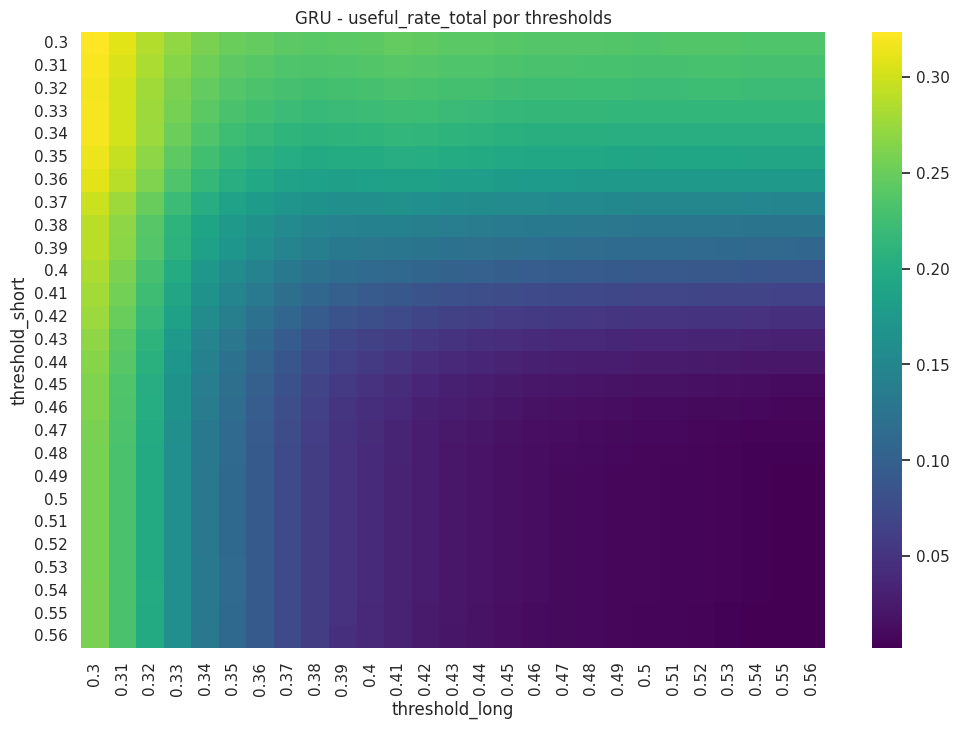

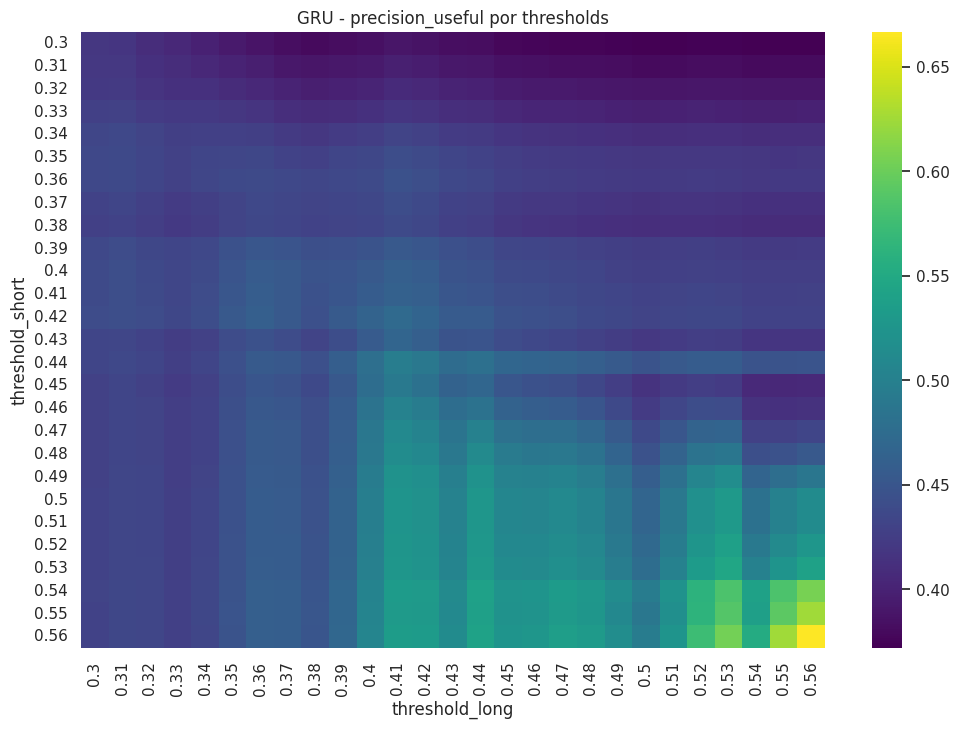

In [29]:
# =========================================================
# 14. Barrido de thresholds para GRU baseline
# =========================================================

df_gru_thr = df_strat.copy()

# ---------------------------------------------------------
# 1. Función para generar señal con thresholds variables
# ---------------------------------------------------------

def build_signal_from_thresholds(
    df: pd.DataFrame,
    proba_long_col: str,
    proba_short_col: str,
    threshold_long: float,
    threshold_short: float,
) -> np.ndarray:
    """
    Genera señales:
        1  = long
       -1  = short
        0  = no trade

    Si long y short superan threshold al mismo tiempo,
    se elige la dirección con mayor probabilidad.
    """

    p_long = df[proba_long_col].values
    p_short = df[proba_short_col].values

    long_mask = p_long >= threshold_long
    short_mask = p_short >= threshold_short

    signal = np.zeros(len(df), dtype=int)

    # Casos sin conflicto
    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    # Casos con conflicto
    conflict_mask = long_mask & short_mask

    signal[conflict_mask & (p_long > p_short)] = 1
    signal[conflict_mask & (p_short > p_long)] = -1
    signal[conflict_mask & (p_long == p_short)] = 0

    return signal


# ---------------------------------------------------------
# 2. Grid de thresholds
# ---------------------------------------------------------

threshold_values = np.round(np.arange(0.30, 0.56, 0.01), 2)

results_thr = []

for thr_long in threshold_values:
    for thr_short in threshold_values:

        signal = build_signal_from_thresholds(
            df=df_gru_thr,
            proba_long_col="gru_proba_1",
            proba_short_col="gru_proba_-1",
            threshold_long=thr_long,
            threshold_short=thr_short,
        )

        tmp = df_gru_thr.copy()
        tmp["signal_gru_thr"] = signal

        metrics = evaluate_strategy(
            df=tmp,
            signal_col="signal_gru_thr",
            name="GRU threshold grid",
        )

        metrics["threshold_long"] = thr_long
        metrics["threshold_short"] = thr_short

        results_thr.append(metrics)


df_gru_threshold_grid = pd.DataFrame(results_thr)

# ---------------------------------------------------------
# 3. Ordenar resultados
# ---------------------------------------------------------

df_gru_threshold_grid = df_gru_threshold_grid.sort_values(
    by=["useful_rate_total", "precision_useful", "trade_rate"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("BARRIDO DE THRESHOLDS - GRU BASELINE")
print("=" * 80)

display(df_gru_threshold_grid.head(20))


# ---------------------------------------------------------
# 4. Top configuraciones con filtros operativos mínimos
# ---------------------------------------------------------

min_trade_rate = 0.05

df_gru_threshold_filtered = df_gru_threshold_grid[
    df_gru_threshold_grid["trade_rate"] >= min_trade_rate
].copy()

df_gru_threshold_filtered = df_gru_threshold_filtered.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print(f"TOP CONFIGURACIONES CON trade_rate >= {min_trade_rate}")
print("=" * 80)

display(df_gru_threshold_filtered.head(20))


# ---------------------------------------------------------
# 5. Heatmap useful_rate_total
# ---------------------------------------------------------

heatmap_useful = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="useful_rate_total",
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_useful,
    cmap="viridis",
    annot=False
)
plt.title("GRU - useful_rate_total por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()


# ---------------------------------------------------------
# 6. Heatmap precision_useful
# ---------------------------------------------------------

heatmap_precision = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="precision_useful",
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_precision,
    cmap="viridis",
    annot=False
)
plt.title("GRU - precision_useful por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()